# Homework 6
## Luther Williams

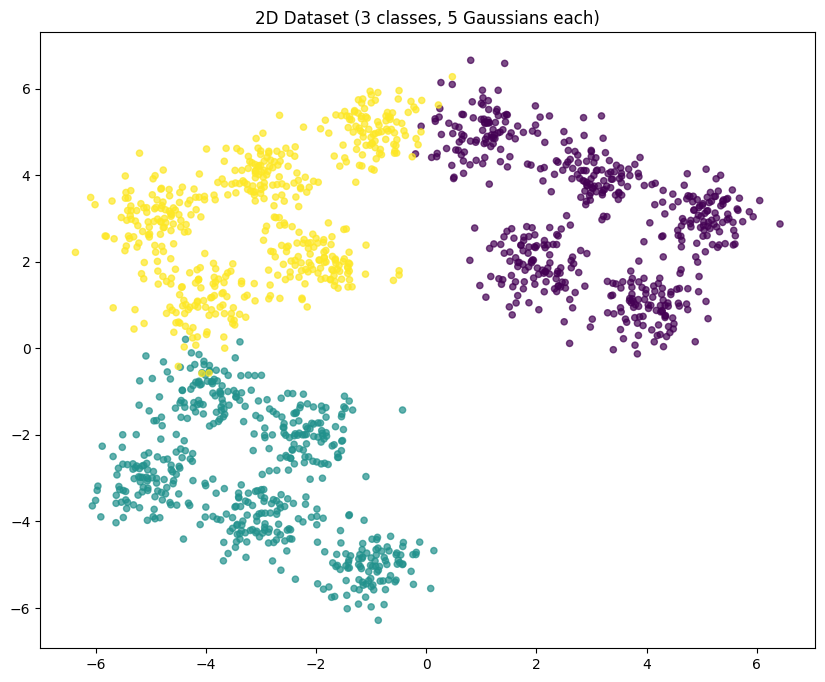

Train size: 900
Validation size: 300
Test size: 300


In [1]:
import numpy as np
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
from collections import Counter
import math

# Generate 2D dataset sampled from 5 Gaussian distributions per class with 3 classes
key = random.PRNGKey(42)

def generate_data(key, n_samples_per_gaussian=100):
    X = []
    y = []
    
    # 3 classes, each with 5 Gaussian clusters
    centers = jnp.array([
        # Class 0 centers
        [[2, 2], [3, 4], [1, 5], [4, 1], [5, 3]],
        # Class 1 centers
        [[-2, -2], [-3, -4], [-1, -5], [-4, -1], [-5, -3]],
        # Class 2 centers
        [[-2, 2], [-3, 4], [-1, 5], [-4, 1], [-5, 3]]
    ])
    
    for class_id in range(3):
        for center in centers[class_id]:
            key, subkey = random.split(key)
            samples = random.normal(subkey, (n_samples_per_gaussian, 2)) * 0.5 + center
            X.append(samples)
            y.append(jnp.full(n_samples_per_gaussian, class_id))
            
    X = jnp.vstack(X)
    y = jnp.concatenate(y)
    return X, y

X, y = generate_data(key, 100) # 1500 total points (3 * 5 * 100)

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=20, alpha=0.7)
plt.title('2D Dataset (3 classes, 5 Gaussians each)')
plt.show()

def train_test_split(key, X, y, test_size=0.2):
    n = len(X)
    indices = random.permutation(key, jnp.arange(n))
    split_idx = int(n * (1 - test_size))
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

key, subkey1, subkey2 = random.split(key, 3)
X_temp, X_test, y_temp, y_test = train_test_split(subkey1, X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(subkey2, X_temp, y_temp, test_size=0.25) # 0.25 x 0.8 = 0.2

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

In [ ]:
# Decision Tree

def entropy(y):
    """Calculate the entropy of a label distribution."""
    hist = np.bincount(y)
    ps = hist / len(y)
    return -np.sum([p * np.log2(p) for p in ps if p > 0])

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None
        
    def fit(self, X, y):
        self.root = self._grow_tree(X, y)
        
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
            
        feat_idxs = np.random.choice(n_features, n_features, replace=False)
        
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)
        
        if best_feat is None:
            return Node(value=self._most_common_label(y))
            
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)
        
        return Node(best_feat, best_thresh, left, right)
        
    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None
        
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
                    
        return split_idx, split_thresh
        
    def _information_gain(self, y, X_column, threshold):
        parent_entropy = entropy(y)
        
        left_idxs, right_idxs = self._split(X_column, threshold)
        
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
            
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = entropy(y[left_idxs]), entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r
        
        ig = parent_entropy - child_entropy
        return ig
        
    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs
        
    def _most_common_label(self, y):
        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common
        
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
        
    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
            
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [3]:
def calculate_metrics(y_true, y_pred):
    """Calculate precision, accuracy, recall, and F1 score manually."""
    
    # Accuracy
    accuracy = jnp.sum(y_true == y_pred) / len(y_true)
    
    # Calculate True Positives, False Positives, False Negatives for each class
    classes = jnp.unique(y_true)
    precisions = []
    recalls = []
    f1s = []
    
    for c in classes:
        tp = jnp.sum((y_pred == c) & (y_true == c))
        fp = jnp.sum((y_pred == c) & (y_true != c))
        fn = jnp.sum((y_pred != c) & (y_true == c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        
    return {
        'accuracy': accuracy,
        'precision': jnp.mean(jnp.array(precisions)), # Macro average
        'recall': jnp.mean(jnp.array(recalls)),
        'f1': jnp.mean(jnp.array(f1s))
    }

# K-Fold Cross Validation
K = 5
def kfold_split(key, n, n_splits):
    indices = random.permutation(key, jnp.arange(n))
    fold_sizes = np.full(n_splits, n // n_splits, dtype=int)
    fold_sizes[:n % n_splits] += 1
    current = 0
    splits = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_idx = indices[start:stop]
        train_idx = jnp.concatenate((indices[:start], indices[stop:]))
        splits.append((train_idx, val_idx))
        current = stop
    return splits

overall_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

X_cv = jnp.vstack((X_train, X_val))
y_cv = jnp.concatenate((y_train, y_val))

print(f"Starting {K}-Fold Cross Validation...")
fold = 1
key, subkey = random.split(key)
for train_index, val_index in kfold_split(subkey, len(X_cv), K):
    X_train_kf, X_val_kf = X_cv[train_index], X_cv[val_index]
    y_train_kf, y_val_kf = y_cv[train_index], y_cv[val_index]
    
    clf = DecisionTree(max_depth=5)
    clf.fit(np.array(X_train_kf), np.array(y_train_kf))
    
    # Predict and evaluate
    predictions = jnp.array(clf.predict(np.array(X_val_kf)))
    metrics = calculate_metrics(y_val_kf, predictions)
    
    overall_metrics['accuracy'].append(metrics['accuracy'])
    overall_metrics['precision'].append(metrics['precision'])
    overall_metrics['recall'].append(metrics['recall'])
    overall_metrics['f1'].append(metrics['f1'])
    
    print(f"Fold {fold} accuracy: {metrics['accuracy']:.4f}")
    fold += 1
    

print("\n--- Cross Validation Summary ---")
for metric_name, values in overall_metrics.items():
    print(f"{metric_name.capitalize()}: {jnp.mean(jnp.array(values)):.4f} (+/- {jnp.std(jnp.array(values)):.4f})")

# Final Test Eror
print("\n--- Final Test Evaluation ---")
final_tree = DecisionTree(max_depth=5)
final_tree.fit(np.array(X_cv), np.array(y_cv))
test_predictions = jnp.array(final_tree.predict(np.array(X_test)))
test_metrics = calculate_metrics(y_test, test_predictions)

for metric_name, value in test_metrics.items():
    print(f"{metric_name.capitalize()}: {value:.4f}")

Starting 5-Fold Cross Validation...
Fold 1 accuracy: 0.9833
Fold 2 accuracy: 0.9917
Fold 3 accuracy: 0.9917
Fold 4 accuracy: 1.0000
Fold 5 accuracy: 0.9875

--- Cross Validation Summary ---
Accuracy: 0.9908 (+/- 0.0055)
Precision: 0.9906 (+/- 0.0057)
Recall: 0.9909 (+/- 0.0055)
F1: 0.9907 (+/- 0.0056)

--- Final Test Evaluation ---
Accuracy: 0.9833
Precision: 0.9837
Recall: 0.9833
F1: 0.9834
